In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import silhouette_score

In [2]:
# Load CSV file

df = pd.read_csv("weather_prediction_picnic_labels.csv")

# Display first rows
df.head()

,DATE,BASEL_picnic_weather,BUDAPEST_picnic_weather,DE_picnic_weather,DRESDEN_picnic_weather,DUSSELDORF_picnic_weather,HEATHROW_picnic_weather,KASSEL_picnic_weather,LJUBLJANA_picnic_weather,MAASTRICHT_picnic_weather,MALMO_picnic_weather,MONTELIMAR_picnic_weather,MUENCHEN_picnic_weather,OSLO_picnic_weather,PERPIGNAN_picnic_weather,SONNBLICK_picnic_weather,STOCKHOLM_picnic_weather,TOURS_picnic_weather
0,20000101,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,20000102,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,20000103,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,20000104,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,20000105,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [3]:
# Dataset shape

print("Rows and Columns:")
print(df.shape)


# Column names

print("\nColumns:")
print(df.columns)


# Dataset information

df.info()

Rows and Columns:
(3654, 18)

Columns:
Index(['DATE', 'BASEL_picnic_weather', 'BUDAPEST_picnic_weather',
       'DE_picnic_weather', 'DRESDEN_picnic_weather',
       'DUSSELDORF_picnic_weather', 'HEATHROW_picnic_weather',
       'KASSEL_picnic_weather', 'LJUBLJANA_picnic_weather',
       'MAASTRICHT_picnic_weather', 'MALMO_picnic_weather',
       'MONTELIMAR_picnic_weather', 'MUENCHEN_picnic_weather',
       'OSLO_picnic_weather', 'PERPIGNAN_picnic_weather',
       'SONNBLICK_picnic_weather', 'STOCKHOLM_picnic_weather',
       'TOURS_picnic_weather'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   DATE                       3654 non-null   int64
 1   BASEL_picnic_weather       3654 non-null   bool 
 2   BUDAPEST_picnic_weather    3654 non-null   bool 
 3   DE_picnic_weather          3654 non-null   bool 
 4 

In [4]:
df.isnull().sum()

DATE                         0
BASEL_picnic_weather         0
BUDAPEST_picnic_weather      0
DE_picnic_weather            0
DRESDEN_picnic_weather       0
DUSSELDORF_picnic_weather    0
HEATHROW_picnic_weather      0
KASSEL_picnic_weather        0
LJUBLJANA_picnic_weather     0
MAASTRICHT_picnic_weather    0
MALMO_picnic_weather         0
MONTELIMAR_picnic_weather    0
MUENCHEN_picnic_weather      0
OSLO_picnic_weather          0
PERPIGNAN_picnic_weather     0
SONNBLICK_picnic_weather     0
STOCKHOLM_picnic_weather     0
TOURS_picnic_weather         0
dtype: int64

In [5]:
df.isnull().sum()

DATE                         0
BASEL_picnic_weather         0
BUDAPEST_picnic_weather      0
DE_picnic_weather            0
DRESDEN_picnic_weather       0
DUSSELDORF_picnic_weather    0
HEATHROW_picnic_weather      0
KASSEL_picnic_weather        0
LJUBLJANA_picnic_weather     0
MAASTRICHT_picnic_weather    0
MALMO_picnic_weather         0
MONTELIMAR_picnic_weather    0
MUENCHEN_picnic_weather      0
OSLO_picnic_weather          0
PERPIGNAN_picnic_weather     0
SONNBLICK_picnic_weather     0
STOCKHOLM_picnic_weather     0
TOURS_picnic_weather         0
dtype: int64

In [6]:
df.describe()

,DATE
count,3.654000e+03
mean,2.004568e+07
std,2.874287e+04
min,2.000010e+07
25%,2.002070e+07
50%,2.004567e+07
75%,2.007070e+07
max,2.010010e+07


In [7]:
# View unique values

for col in df.columns:
    print("\nColumn:", col)
    print(df[col].unique()[:10])


Column: DATE
[20000101 20000102 20000103 20000104 20000105 20000106 20000107 20000108
 20000109 20000110]

Column: BASEL_picnic_weather
[False  True]

Column: BUDAPEST_picnic_weather
[False  True]

Column: DE_picnic_weather
[False  True]

Column: DRESDEN_picnic_weather
[False  True]

Column: DUSSELDORF_picnic_weather
[False  True]

Column: HEATHROW_picnic_weather
[False  True]

Column: KASSEL_picnic_weather
[False  True]

Column: LJUBLJANA_picnic_weather
[False  True]

Column: MAASTRICHT_picnic_weather
[False  True]

Column: MALMO_picnic_weather
[False  True]

Column: MONTELIMAR_picnic_weather
[False  True]

Column: MUENCHEN_picnic_weather
[False  True]

Column: OSLO_picnic_weather
[False  True]

Column: PERPIGNAN_picnic_weather
[False  True]

Column: SONNBLICK_picnic_weather
[False]

Column: STOCKHOLM_picnic_weather
[False  True]

Column: TOURS_picnic_weather
[False  True]


In [8]:
# Convert all columns into one text column for NLP

df["text_data"] = df.astype(str).apply(
    lambda x: " ".join(x),
    axis=1
)

df["text_data"].head()

0    20000101 False False False False False False F...
1    20000102 False False False False False False F...
2    20000103 False False False False False False F...
3    20000104 False False False False False False F...
4    20000105 False False False False False False F...
Name: text_data, dtype: str

In [9]:
tfidf = TfidfVectorizer(
    stop_words="english"
)


X_text = tfidf.fit_transform(
    df["text_data"]
)


print(X_text.shape)

(3654, 3656)


In [10]:
X = pd.DataFrame(
    X_text.toarray(),
    columns=tfidf.get_feature_names_out()
)


X.head()

,20000101,20000102,20000103,20000104,20000105,20000106,20000107,20000108,20000109,20000110,...,20091225,20091226,20091227,20091228,20091229,20091230,20091231,20100101,false,true
0,0.447664,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.894202,0.0
1,0.000000,0.447664,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.894202,0.0
2,0.000000,0.000000,0.447664,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.894202,0.0
3,0.000000,0.000000,0.000000,0.447664,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.894202,0.0
4,0.000000,0.000000,0.000000,0.000000,0.447664,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.894202,0.0


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 6.04400529e+01, -1.65453197e-02, -1.65453197e-02, ...,
        -1.65453197e-02,  7.48682078e-01, -9.48940560e-01],
       [-1.65453197e-02,  6.04400529e+01, -1.65453197e-02, ...,
        -1.65453197e-02,  7.48682078e-01, -9.48940560e-01],
       [-1.65453197e-02, -1.65453197e-02,  6.04400529e+01, ...,
        -1.65453197e-02,  7.48682078e-01, -9.48940560e-01],
       ...,
       [-1.65453197e-02, -1.65453197e-02, -1.65453197e-02, ...,
        -1.65453197e-02,  7.48682078e-01, -9.48940560e-01],
       [-1.65453197e-02, -1.65453197e-02, -1.65453197e-02, ...,
        -1.65453197e-02,  7.48682078e-01, -9.48940560e-01],
       [-1.65453197e-02, -1.65453197e-02, -1.65453197e-02, ...,
         6.04400529e+01,  7.48682078e-01, -9.48940560e-01]],
      shape=(3654, 3656))

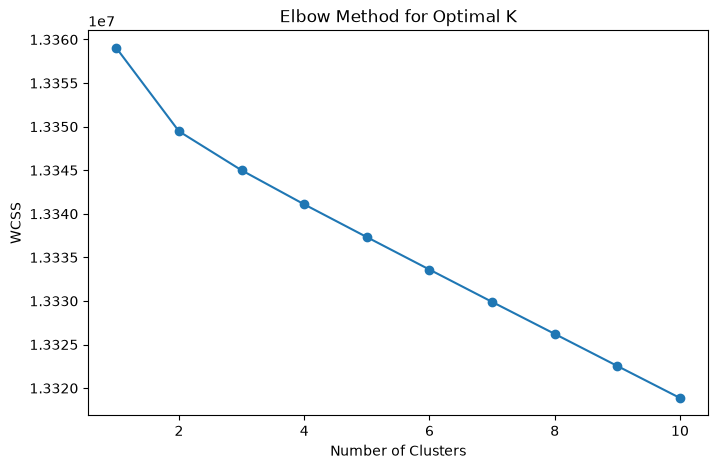

In [12]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title(
    "Elbow Method for Optimal K"
)

plt.show()

In [15]:
df.to_csv(
    "weather_prediction_picnic_kmeans_results.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!
